# Miniprosjekt 2

In [189]:
import simpy
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


TRIAGE_MEAN = 10
DOCTOR_MEAN = 60

priority_map = {
    2: 0,   
    1: 1,   
    0: 2    
}

In [190]:
# Lamda tabell
def load_lambda_table(filename):
    df = pd.read_excel(filename, header=None)
    df = df[[0,1]].dropna()

    records = []
    current = {}

    for label, value in df.values:
        if label == "Pasientgruppe":
            current = {"group": value}
        elif label == "Dag":
            current["day"] = int(value)
        elif label == "Time":
            current["hour"] = int(value)
        elif label == "Lambda":
            current["lambda"] = float(value)
            records.append(current)

    group_map = {"Grønn":0, "Gul":1, "Rød":2}

    lambda_table = np.zeros((3,7,24))

    for r in records:
        g = group_map[r["group"]]
        d = r["day"] - 1
        h = r["hour"] - 1
        lambda_table[g, d, h] = r["lambda"]

    return lambda_table

In [191]:
# Logg variabler
log_triage_nurse_load = []
log_doctor_load = []
log_triage_wait = []
log_doctor_wait = {0:[], 1:[], 2:[]}
log_bed_usage_hourly = []

In [192]:
# Ressurser 
def create_resources(env):
    triage_beds = simpy.Resource(env, capacity=10)
    triage_nurses = simpy.Resource(env, capacity=5)
    doctors = simpy.PriorityResource(env, capacity=5)
    return triage_beds, triage_nurses, doctors

In [193]:
# Definere passienter
def patient(env, group, triage_beds, triage_nurses, doctors):

    arrival_time = env.now

    # Triageseng
    with triage_beds.request() as bed_req:
        yield bed_req

        # Sykepleier
        with triage_nurses.request() as nurse_req:
            yield nurse_req

            # Logg ventetid til triage
            triage_wait = env.now - arrival_time
            log_triage_wait.append(triage_wait)

            # Triage tid
            yield env.timeout(random.expovariate(1/TRIAGE_MEAN))

    # Ventetid lege
    start_wait_doctor = env.now

    with doctors.request(priority=priority_map[group]) as doc_req:
        yield doc_req

        wait_doc = env.now - start_wait_doctor
        log_doctor_wait[group].append(wait_doc)

        yield env.timeout(random.expovariate(1/DOCTOR_MEAN))

In [194]:
# Ankomstprosses
def arrival_process(env, group, lambda_table, triage_beds, triage_nurses, doctors):
    while True:

        day = int((env.now // (24*60)) % 7)
        hour = int((env.now // 60) % 24)

        lam = lambda_table[group, day, hour]

        interarrival = random.expovariate(lam) if lam > 0 else 60
        yield env.timeout(interarrival)

        env.process(patient(env, group,
                            triage_beds, triage_nurses, doctors))

In [195]:
# Loggføre data 
def monitor(env, triage_nurses, doctors):
    while True:
        log_triage_nurse_load.append(triage_nurses.count + len(triage_nurses.queue))
        log_doctor_load.append(doctors.count + len(doctors.queue))
        log_bed_usage_hourly.append(doctors.count)
        yield env.timeout(60)

In [196]:
# Definere simulering
def run_simulation(filename='Input_miniprosjekt.xlsx', sim_hours=24*7):

    lambda_table = load_lambda_table(filename)

    env = simpy.Environment()

    triage_beds, triage_nurses, doctors = create_resources(env)

    # Start monitor
    env.process(monitor(env, triage_nurses, doctors))

    # Start ankomster
    for g in range(3):
        env.process(arrival_process(env, g, lambda_table,
                                    triage_beds, triage_nurses, doctors))

    env.run(until=sim_hours * 60)


In [197]:
# Kjører simmulasjon for 3 uker
run_simulation(sim_hours=24*7*3)

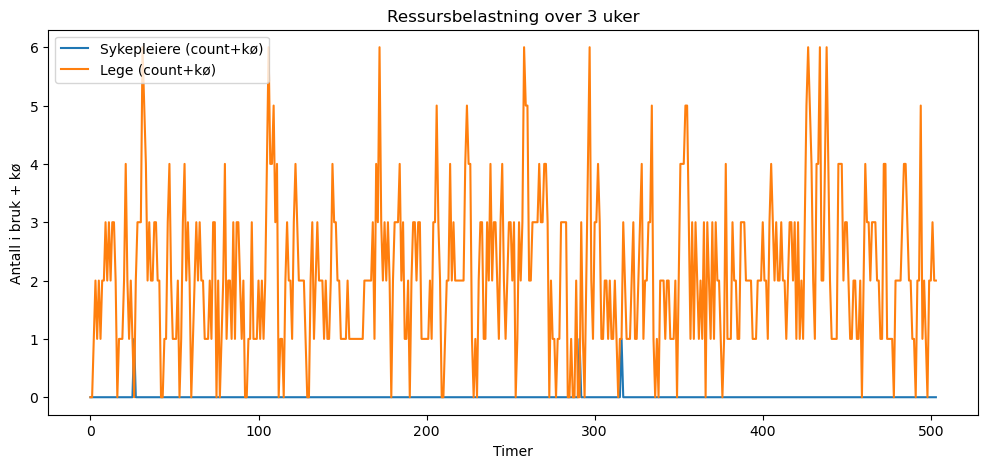

In [198]:
plt.figure(figsize=(12,5))
plt.plot(log_triage_nurse_load, label="Sykepleiere (count+kø)")
plt.plot(log_doctor_load, label="Lege (count+kø)")
plt.legend()
plt.title("Ressursbelastning over 3 uker")
plt.xlabel("Timer")
plt.ylabel("Antall i bruk + kø")
plt.show()

a) Grafen viser at passienter aldri venter på sykepleier og 5 er nok. Grafen over leger viser at den etter en liten warmup også stabiliserer seg rundt 2-6. Det virker som systemet har nok kapasitet 

In [199]:
def run_one_week(warmup_hours=10):
    # Nullstill logger
    global log_triage_nurse_load, log_doctor_load, log_triage_wait, log_doctor_wait, log_bed_usage_hourly
    log_triage_nurse_load = []
    log_doctor_load = []
    log_triage_wait = []
    log_doctor_wait = {0:[], 1:[], 2:[]}
    log_bed_usage_hourly = []

    # Kjør simulering (warmup + 1 uke)
    run_simulation(sim_hours = warmup_hours + 24*7)

    # Returner timevis sengebelegg etter warmup
    return np.array(log_bed_usage_hourly[warmup_hours : warmup_hours + 24*7])

In [200]:
def run_replications(n, warmup_hours=10):
    results = []
    for i in range(n):
        week_data = run_one_week(warmup_hours)
        results.append(week_data)
    return np.array(results)    

In [201]:
res20 = run_replications(20)
res100 = run_replications(100)

In [202]:
def compute_mean_CI(data):
    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0, ddof=1)
    n = data.shape[0]
    se = std / np.sqrt(n)
    CI_low = mean - 1.96 * se
    CI_high = mean + 1.96 * se
    return mean, CI_low, CI_high
mean20, low20, high20 = compute_mean_CI(res20)
mean100, low100, high100 = compute_mean_CI(res100)

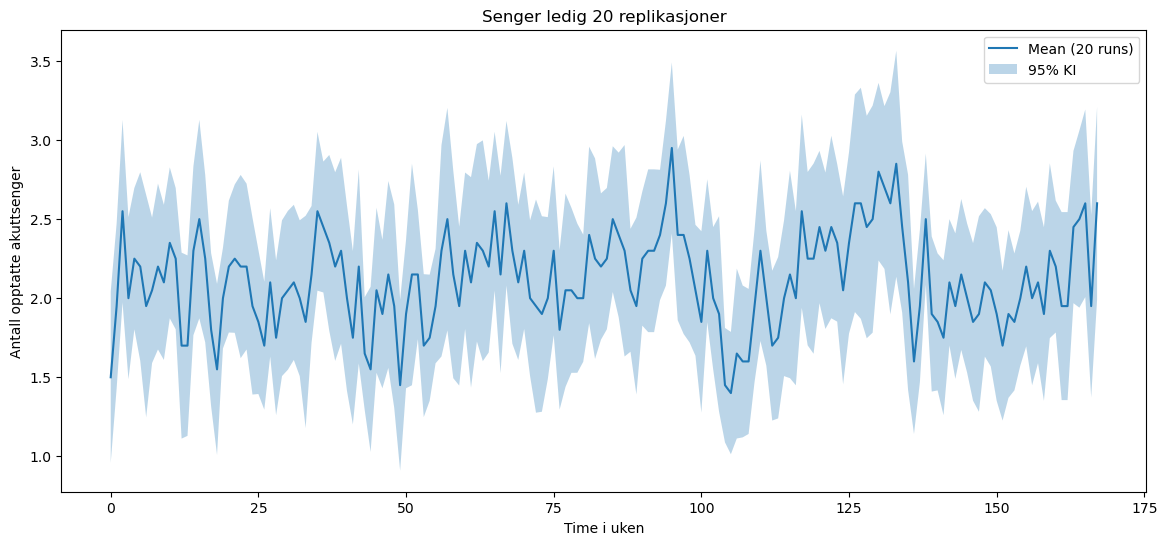

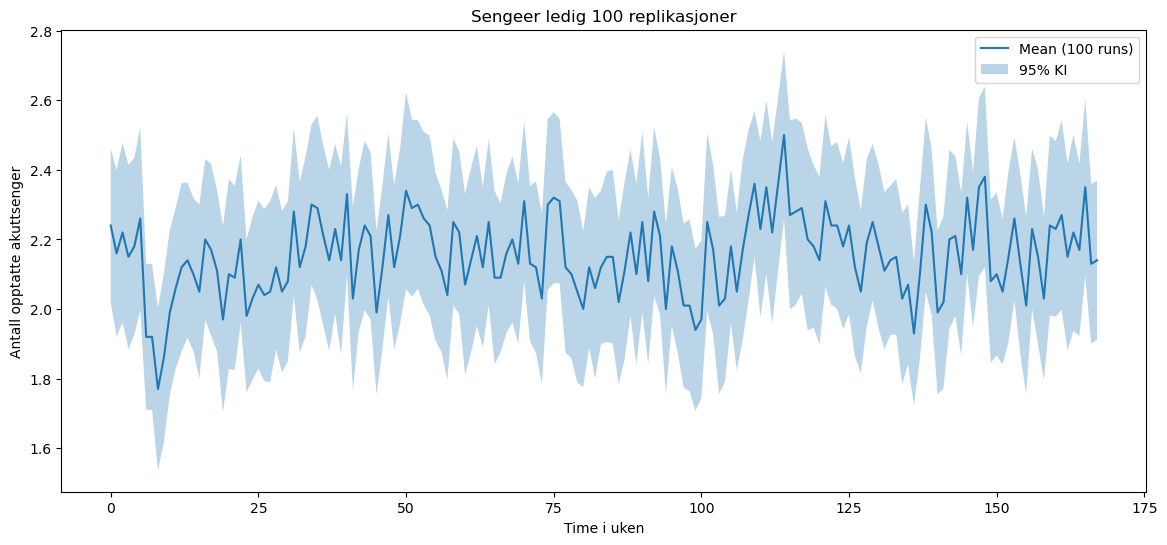

In [203]:
hours = np.arange(168) 

plt.figure(figsize=(14,6))
plt.plot(hours, mean20, label="Mean (20 runs)")
plt.fill_between(hours, low20, high20, alpha=0.3, label="95% KI")
plt.legend()
plt.title("Senger ledig 20 replikasjoner")
plt.xlabel("Time i uken")
plt.ylabel("Antall opptatte akuttsenger")
plt.show()


plt.figure(figsize=(14,6))
plt.plot(hours, mean100, label="Mean (100 runs)")
plt.fill_between(hours, low100, high100, alpha=0.3, label="95% KI")
plt.legend()
plt.title("Sengeer ledig 100 replikasjoner")
plt.xlabel("Time i uken")
plt.ylabel("Antall opptatte akuttsenger")
plt.show()

b) Hovedforskjellen mellom de to simulleringene er at den med 100 er mer nøyaktig. Vi ser at 20 simuleringer ligger grafen rundt 1,5-3 ca mens 100 simuleringer ligger den fra 1,8 - 2,4. Dette vises også i konfidensintervallene som følger ganske like tett for begge grafene, men 100 simuleringsgrafen er mindre i skala. Dette er en helt naturlig og forventet forskjell siden høyere antall simuleringer fører til mer nøyaktig resultat

In [204]:
def run_one_week_triage(warmup_hours=10):
    # nullstill logger
    global log_triage_nurse_load, log_doctor_load, log_triage_wait, log_doctor_wait, log_bed_usage_hourly
    log_triage_nurse_load = []
    log_doctor_load = []
    log_triage_wait = []
    log_doctor_wait = {0:[], 1:[], 2:[]}
    log_bed_usage_hourly = []

    # kjør simulering (warmup + 1 uke)
    run_simulation(sim_hours = warmup_hours + 24*7)

    # returner kun triage-ventetider ETTER warmup
    return np.array(log_triage_wait)

In [205]:
def run_100_weeks_triage():
    weekly_means = []
    weekly_p95 = []

    for i in range(100):
        waits = run_one_week_triage()

        if len(waits) == 0: # Fortsetter selv om kø = 0
            continue

        weekly_means.append(np.mean(waits))
        weekly_p95.append(np.percentile(waits, 95))

    return np.array(weekly_means), np.array(weekly_p95)

mean_list, p95_list = run_100_weeks_triage()

In [206]:
def CI(data):
    n = len(data)
    mean = np.mean(data)
    se = np.std(data, ddof=1) / np.sqrt(n)
    CI_low = mean - 1.96 * se
    CI_high = mean + 1.96 * se
    return mean, CI_low, CI_high
mean_mean, mean_CI_low, mean_CI_high = CI(mean_list)
p95_mean, p95_CI_low, p95_CI_high   = CI(p95_list)

In [207]:
print("Gjennomsnittlig ventetid til triage:")
print(f"  Gjennomsnitt over 100 uker = {mean_mean:.3f}")
print(f"  95% KI = [{mean_CI_low:.3f}, {mean_CI_high:.3f}]")

print("\n95-persentil ventetid til triage:")
print(f"  95-persentil over 100 uker = {p95_mean:.3f}")
print(f"  95% KI = [{p95_CI_low:.3f}, {p95_CI_high:.3f}]")

Gjennomsnittlig ventetid til triage:
  Gjennomsnitt over 100 uker = 0.000
  95% KI = [0.000, 0.000]

95-persentil ventetid til triage:
  95-persentil over 100 uker = 0.000
  95% KI = [0.000, 0.000]


c) Som vi ser er det ingen ventetid på sykepleiere i modellen vår. Dette samspiller med grafen vi så på tidligere om at kø hos sykepleiere var 0

In [208]:
def run_one_week_doctor(warmup_hours=10):
    global log_triage_nurse_load, log_doctor_load, log_triage_wait, log_doctor_wait, log_bed_usage_hourly

    # Nullstill logger
    log_triage_nurse_load = []
    log_doctor_load = []
    log_triage_wait = []
    log_doctor_wait = {0:[], 1:[], 2:[]}
    log_bed_usage_hourly = []

    # Kjør simulering (warmup + 1 uke)
    run_simulation(sim_hours = warmup_hours + 24*7)

    # Returner ventetidene per gruppe etter warmup
    return (
        np.array(log_doctor_wait[0]),  # grønn
        np.array(log_doctor_wait[1]),  # gul
        np.array(log_doctor_wait[2])   # rød
    )

In [209]:
def run_100_weeks_doctor():
    mean_g = []; p95_g = []
    mean_y = []; p95_y = []
    mean_r = []; p95_r = []

    for i in range(100):
        waits_g, waits_y, waits_r = run_one_week_doctor()

        if len(waits_g)>0:
            mean_g.append(np.mean(waits_g))
            p95_g.append(np.percentile(waits_g, 95))

        if len(waits_y)>0:
            mean_y.append(np.mean(waits_y))
            p95_y.append(np.percentile(waits_y, 95))

        if len(waits_r)>0:
            mean_r.append(np.mean(waits_r))
            p95_r.append(np.percentile(waits_r, 95))

    return (np.array(mean_g), np.array(p95_g),
            np.array(mean_y), np.array(p95_y),
            np.array(mean_r), np.array(p95_r))

mean_g, p95_g, mean_y, p95_y, mean_r, p95_r = run_100_weeks_doctor()

In [210]:
def KI_lege(data):
    n = len(data)
    mean = np.mean(data)
    se = np.std(data, ddof=1) / np.sqrt(n)
    return mean, mean - 1.96*se, mean + 1.96*se

In [211]:
mean_g_mean, mean_g_low, mean_g_high = KI_lege(mean_g)
mean_y_mean, mean_y_low, mean_y_high = KI_lege(mean_y)
mean_r_mean, mean_r_low, mean_r_high = KI_lege(mean_r)

p95_g_mean, p95_g_low, p95_g_high = KI_lege(p95_g)
p95_y_mean, p95_y_low, p95_y_high = KI_lege(p95_y)
p95_r_mean, p95_r_low, p95_r_high = KI_lege(p95_r)


In [212]:
print("== Gjennomsnittlig ventetid til lege ==")
print(f"Grønn: {mean_g_mean:.3f}  KI=[{mean_g_low:.3f}, {mean_g_high:.3f}]")
print(f"Gul:   {mean_y_mean:.3f}  KI=[{mean_y_low:.3f}, {mean_y_high:.3f}]")
print(f"Rød:   {mean_r_mean:.3f}  KI=[{mean_r_low:.3f}, {mean_r_high:.3f}]")

print("\n== 95-persentil ventetid til lege ==")
print(f"Grønn: {p95_g_mean:.3f}  KI=[{p95_g_low:.3f}, {p95_g_high:.3f}]")
print(f"Gul:   {p95_y_mean:.3f}  KI=[{p95_y_low:.3f}, {p95_y_high:.3f}]")
print(f"Rød:   {p95_r_mean:.3f}  KI=[{p95_r_low:.3f}, {p95_r_high:.3f}]")

== Gjennomsnittlig ventetid til lege ==
Grønn: 2.476  KI=[2.154, 2.799]
Gul:   1.700  KI=[1.528, 1.871]
Rød:   1.227  KI=[1.100, 1.354]

== 95-persentil ventetid til lege ==
Grønn: 14.850  KI=[12.534, 17.165]
Gul:   10.982  KI=[9.568, 12.396]
Rød:   8.178  KI=[6.998, 9.359]


d) Utskriften viser en naturlig nedgang i ventetid utifra prioriteringsgrad noe som er naturlig og det vi ønsker

### 4.)

In [213]:
DOCTOR_MEAN = 30       
BLOOD_PROB = 0.40      
LAB_TIME = 60          
EVAL_TIME = 5

In [214]:
# Må legge til elementer i passientprossesen 
def patient(env, group, triage_beds, triage_nurses, doctors):

    arrival_time = env.now

    
    with triage_beds.request() as bed_req:
        yield bed_req
        with triage_nurses.request() as nurse_req:
            yield nurse_req

            triage_wait = env.now - arrival_time
            log_triage_wait.append(triage_wait)

            
            yield env.timeout(random.expovariate(1 / TRIAGE_MEAN))

   
    start_wait_doc = env.now

    with doctors.request(priority=priority_map[group]) as doc_req:
        yield doc_req

        wait_doc = env.now - start_wait_doc
        log_doctor_wait[group].append(wait_doc)

        
        yield env.timeout(random.expovariate(1 / DOCTOR_MEAN))

    
    blodprove= random.random() < BLOOD_PROB

    if blodprove:
       
        time_to_next_hour = 60 - (env.now % 60)
        yield env.timeout(time_to_next_hour)

        
        yield env.timeout(LAB_TIME)

        
        start_eval_wait = env.now

        with doctors.request(priority=priority_map[group]) as eval_req:
            yield eval_req

            eval_wait = env.now - start_eval_wait
            log_doctor_wait[group].append(eval_wait)

            
            yield env.timeout(EVAL_TIME)

    return

In [215]:
# Trenger ny monitor funksjon
def monitor(env, triage_nurses, doctors):
    while True:
        
        in_doctor = doctors.count
        
        
        waiting_for_doc = len(doctors.queue)

        
        beds_in_use = in_doctor + waiting_for_doc

        log_bed_usage_hourly.append(doctors.count + len(doctors.queue))

        
        log_triage_nurse_load.append(triage_nurses.count + len(triage_nurses.queue))
        log_doctor_load.append(doctors.count + len(doctors.queue))

        yield env.timeout(60)

In [216]:
log_doctor_load = []
log_triage_nurse_load = []
log_bed_usage_hourly = []

run_simulation(sim_hours=24*7*3)

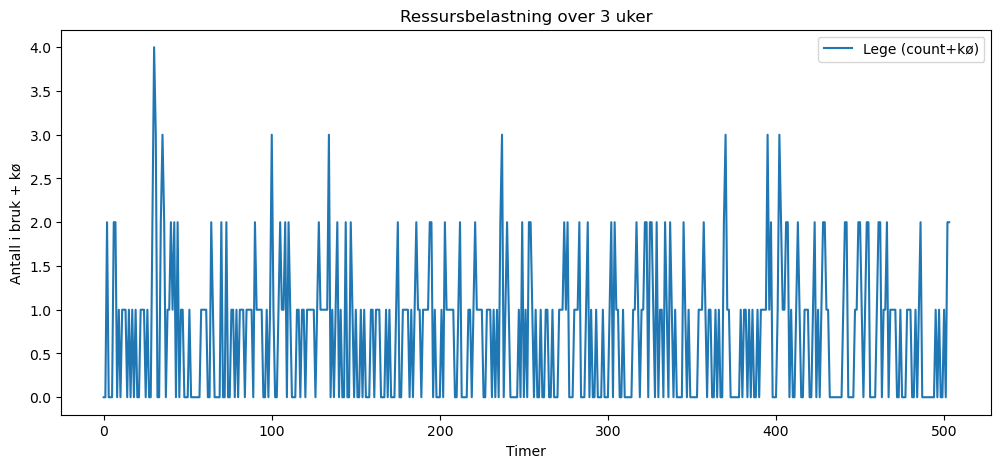

In [217]:
# Ser på samme plot som tidligere
plt.figure(figsize=(12,5))
plt.plot(log_doctor_load, label="Lege (count+kø)")
plt.legend()
plt.title("Ressursbelastning over 3 uker")
plt.xlabel("Timer")
plt.ylabel("Antall i bruk + kø")
plt.show()

b) Vi ser at systemet forsatt er stabilt, la oss nå se på estimatet for akuttsenger som opptas

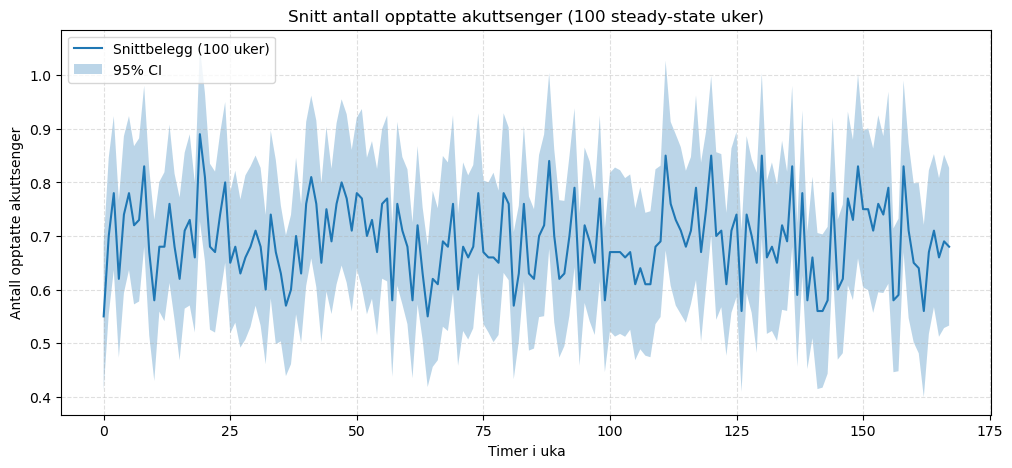

In [218]:
res100 = run_replications(100, warmup_hours=10)


plt.figure(figsize=(12,5))
plt.plot(mean, label="Snittbelegg (100 uker)")
plt.fill_between(np.arange(168), low, high, alpha=0.3, label="95% CI")
plt.title("Snitt antall opptatte akuttsenger (100 steady-state uker)")
plt.xlabel("Timer i uka")
plt.ylabel("Antall opptatte akuttsenger")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.show()


Det virker som systemet forsatt ikke er tungt belastet og vi trenger ikke øke noen ressurser